# M2a: EEG's own cross-session reliability (derived features)

`PLANssvep_bh_fm100.md` M2: before leaning on the two *derived* EEG
features -- `ramp_magnitude` (severity) and the ramp-vector's angle
(type/axis) -- check whether they're consistent session-to-session, same
precedent M1 set for FM100. `ramp_slope_red`/`ramp_intercept`'s own
reliability is already established (`ssveps/`'s M9, ICC 0.85/0.90); this
only needs to check the two new composite quantities built from them.

Going in, we already know from `docs/ssvepbeh_reliability_gaps.md` that
per-subtype reliability won't be assessable: protan and CVD (combined)
have only 2 subjects with EEG data at both sessions, deutan has 0. Not a
surprise to discover here -- stated upfront.

In [1]:
import sys
sys.path.append('../scripts')

import eeg_features

# eeg_features imports fm100_features internally (for its already-resolved
# ssveps "reliability" module), which inserts ssveps/scripts at
# sys.path[0] as a side effect -- ssveps/scripts has its own plotting.py
# too, so re-assert this project's scripts/ first before resolving
# "plotting", or it would silently import ssveps' version instead.
sys.path.insert(0, '../scripts')
import plotting

troughs = eeg_features.load_subject_troughs()
print(f"{troughs['sub_id'].nunique()} subjects, {len(troughs)} (subject, session) rows")

43 subjects, 62 (subject, session) rows


## Reliability table (pooled)

In [2]:
reliability = eeg_features.reliability_table(troughs)
reliability

,feature,n,statistic,value,p_value
0,ramp_magnitude,19,icc,0.652003,0.001002
1,ramp_angle_deg,19,circ_r,0.688792,0.011710


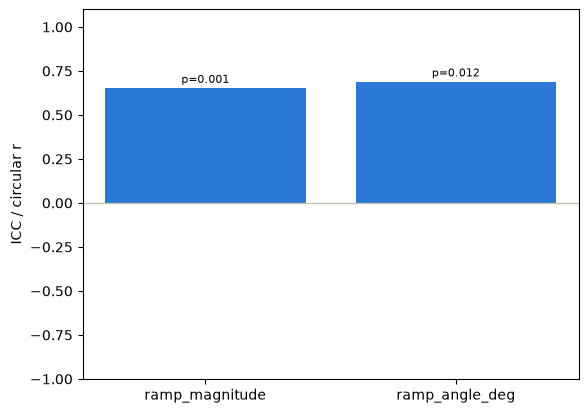

In [3]:
plotting.plot_reliability_table(reliability);

**`ramp_magnitude`'s reliability (ICC=0.65) is notably lower than
`ramp_slope_red`'s own established reliability (ICC=0.85, M9)** --
combining it with `ramp_slope_green` (whose own individual reliability
was never separately reported) seems to have diluted it, not improved it.
`ramp_angle_deg` fares a bit better (circular r=0.69, p=0.012) but is
still far from the >0.8 bar M9 used to call a measure "reliable enough to
build on." Both derived features are usable but noisier than the raw
`ramp_slope_red`/`ramp_intercept` they're built from -- worth remembering
when interpreting `04_fm100_vs_eeg.ipynb`.

## Per-group breakdown -- where it's even computable

In [4]:
for label, kw in [('CTR', dict(group='CTR')), ('PD', dict(group='PD')), ('CVD', dict(group='CVD')), ('protan', dict(group='CVD', subgroup='protan')), ('deutan', dict(group='CVD', subgroup='deutan'))]:
    try:
        r = eeg_features.reliability_table(troughs, **kw)
        print(f'--- {label} ---')
        print(r.to_string(index=False))
    except ValueError as e:
        print(f'{label}: {e}')
    print()

--- CTR ---
       feature  n statistic    value  p_value
ramp_magnitude 13       icc 0.471467 0.050491
ramp_angle_deg 13    circ_r 0.641654 0.059420



--- PD ---
       feature  n statistic    value  p_value
ramp_magnitude  4       icc 0.908718 0.021628
ramp_angle_deg  4    circ_r 0.992921 0.050468

CVD: only 2 subjects have EEG data at both session 1 and 2 (need >= 3)

protan: only 2 subjects have EEG data at both session 1 and 2 (need >= 3)

deutan: only 0 subjects have EEG data at both session 1 and 2 (need >= 3)



As expected: CVD (combined), protan, and deutan all raise (2, 2, and 0
paired subjects respectively). CTR (n=13) and PD (n=4) compute, though
PD's n=4 is thin enough that its high point estimates (ICC=0.91,
circular r=0.99) shouldn't be read as more solid than pooled/CTR's.

## Verdict for M2b

Proceed to `04_fm100_vs_eeg.ipynb` with both derived features, carrying
their moderate (not strong) reliability forward as an explicit caveat --
same posture M1 took with `VKS_Angle`.